# Getting started with pyAFQ - ParticipantAFQ


In [5]:
import os
import os.path as op

import matplotlib.pyplot as plt
import nibabel as nib
import plotly

from AFQ.api.participant import ParticipantAFQ
import AFQ.data.fetch as afd
import AFQ.definitions.image as afm


In [6]:
afd.fetch_hbn_preproc(["NDARAA948VFH"])


({'/Users/applejuiceleigh/AFQ_data/HBN/derivatives/qsiprep/sub-NDARAA948VFH/anat/sub-NDARAA948VFH_desc-brain_mask.nii.gz': 'data/Projects/HBN/BIDS_curated/derivatives/qsiprep/sub-NDARAA948VFH/anat/sub-NDARAA948VFH_desc-brain_mask.nii.gz',
  '/Users/applejuiceleigh/AFQ_data/HBN/derivatives/qsiprep/sub-NDARAA948VFH/anat/sub-NDARAA948VFH_desc-preproc_T1w.nii.gz': 'data/Projects/HBN/BIDS_curated/derivatives/qsiprep/sub-NDARAA948VFH/anat/sub-NDARAA948VFH_desc-preproc_T1w.nii.gz',
  '/Users/applejuiceleigh/AFQ_data/HBN/derivatives/qsiprep/sub-NDARAA948VFH/anat/sub-NDARAA948VFH_dseg.nii.gz': 'data/Projects/HBN/BIDS_curated/derivatives/qsiprep/sub-NDARAA948VFH/anat/sub-NDARAA948VFH_dseg.nii.gz',
  '/Users/applejuiceleigh/AFQ_data/HBN/derivatives/qsiprep/sub-NDARAA948VFH/anat/sub-NDARAA948VFH_from-MNI152NLin2009cAsym_to-T1w_mode-image_xfm.h5': 'data/Projects/HBN/BIDS_curated/derivatives/qsiprep/sub-NDARAA948VFH/anat/sub-NDARAA948VFH_from-MNI152NLin2009cAsym_to-T1w_mode-image_xfm.h5',
  '/Users/

In [7]:
tracking_params = dict(n_seeds=1e5,
                       random_seeds=True,
                       rng_seed=2025,
                       trx=True)
pve = afm.PVEImages(
    afm.ImageFile(
        suffix="probseg", filters={"scope": "qsiprep", "label": "CSF"}),
    afm.ImageFile(
        suffix="probseg", filters={"scope": "qsiprep", "label": "GM"}),
    afm.ImageFile(
        suffix="probseg", filters={"scope": "qsiprep", "label": "WM"}))
brain_mask_definition = afm.ImageFile(
    suffix="mask", filters={"desc": "brain", "scope": "qsiprep"})
myafq = GroupAFQ(
    bids_path=op.join(afd.afq_home, 'HBN'),
    dwi_preproc_pipeline='qsiprep',
    t1_preproc_pipeline='qsiprep',
    participant_labels=['NDARAA948VFH'],
    pve=pve,
    brain_mask_definition=brain_mask_definition,
    tracking_params=tracking_params)


NameError: name 'GroupAFQ' is not defined

In [6]:
brain_mask_definition

In [7]:
FA_fname = myafq.export("dti_fa", collapse=False)["NDARAA948VFH"]["HBNsiteRU"]

#  use `nibabel` to load the deriviative file and retrieve the data array.

FA_img = nib.load(FA_fname)
FA = FA_img.get_fdata()

INFO:AFQ:Calculating _b0ref.nii.gz...
INFO:AFQ:_b0ref.nii.gz completed. Saving to /Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_b0ref.nii.gz
INFO:AFQ:Calculating _desc-brain_mask.nii.gz...
INFO:AFQ:Calculating _desc-T1w_mask.nii.gz...
INFO:AFQ:_desc-T1w_mask.nii.gz completed. Saving to /Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_desc-T1w_mask.nii.gz
INFO:AFQ:_desc-brain_mask.nii.gz completed. Saving to /Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_desc-brain_mask.nii.gz
INFO:AFQ:Calculating _model-tensor_param-diffusivity_dwimap.nii.gz, _model-tensor_param-s0_dwimap.nii.gz...
INFO:AFQ:_model-tensor_param-diffusivity_dwimap.nii.gz completed. Saving to /Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/models

In [9]:
DATASET = Path(
    "/Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq"
)

SUBJECT = "sub-ON01016"

subject_folder = DATASET / SUBJECT

subject_folder

PosixPath('/Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-ON01016')

(np.float64(-0.5), np.float64(128.5), np.float64(107.5), np.float64(-0.5))

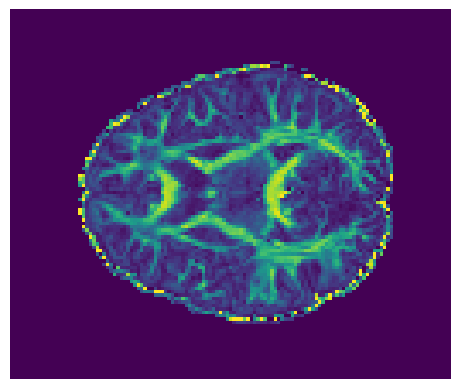

In [10]:
fig, ax = plt.subplots(1)
ax.matshow(FA[:, :, FA.shape[-1] // 2], cmap='viridis')
ax.axis("off")


In [3]:
import AFQ.data.fetch as afd
import time

fetchers = [
    afd.fetch_or_templates,
    afd.fetch_templates,
    afd.fetch_callosum_templates,
    afd.fetch_slf_templates,
    afd.fetch_ar_templates,
    afd.fetch_hcp_atlas_16_bundles,
]

for fn in fetchers:
    print(f"Running {fn.__name__}...")
    fn()
    print(f"  ✓ done — waiting 15s before next fetch...")
    time.sleep(15)

Running fetch_or_templates...
[2026-08-07 16:05:54][dipy] INFO: Downloading "left_thal_MNI.nii.gz" to /Users/applejuiceleigh/AFQ_data/or_templates
[2026-08-07 16:05:54][dipy] INFO: From: https://ndownloader.figshare.com/files/36514170


  0%|          | 0/1 MB [00:00]

[2026-08-07 16:05:57][dipy] INFO: Downloading "left_V1_MNI.nii.gz" to /Users/applejuiceleigh/AFQ_data/or_templates
[2026-08-07 16:05:57][dipy] INFO: From: https://ndownloader.figshare.com/files/26831633


  0%|          | 0/1 MB [00:00]

[2026-08-07 16:06:00][dipy] INFO: Downloading "right_thal_MNI.nii.gz" to /Users/applejuiceleigh/AFQ_data/or_templates
[2026-08-07 16:06:00][dipy] INFO: From: https://ndownloader.figshare.com/files/36514173


...

[2026-08-07 16:13:00][dipy] INFO: Downloading "AAL_TempSup_L.nii.gz" to /Users/applejuiceleigh/AFQ_data/ar_templates
[2026-08-07 16:13:00][dipy] INFO: From: https://ndownloader.figshare.com/files/43817373


  0%|          | 0/16 MB [00:00]

[2026-08-07 16:13:02][dipy] INFO: Downloading "AAL_TempSup_R.nii.gz" to /Users/applejuiceleigh/AFQ_data/ar_templates
[2026-08-07 16:13:02][dipy] INFO: From: https://ndownloader.figshare.com/files/43817376


  0%|          | 0/16 MB [00:00]

[2026-08-07 16:13:05][dipy] INFO: Files successfully downloaded to /Users/applejuiceleigh/AFQ_data/ar_templates
  ✓ done — waiting 15s before next fetch...
Running fetch_hcp_atlas_16_bundles...
  ✓ done — waiting 15s before next fetch...


In [4]:
myafq.export('profiles')


NameError: name 'myafq' is not defined

In [20]:
nib.load("/Users/applejuiceleigh/AFQ_data/or_templates/left_OP_MNI.nii.gz")

ImageFileError: File /Users/applejuiceleigh/AFQ_data/or_templates/left_OP_MNI.nii.gz is not a gzip file

In [17]:
bundle_html = myafq.export("all_bundles_figure", collapse=False)
plotly.io.show(bundle_html["NDARAA948VFH"]["HBNsiteRU"][0])


INFO:AFQ:Calculating _model-tensor_param-md_dwimap.nii.gz...
INFO:AFQ:_model-tensor_param-md_dwimap.nii.gz completed. Saving to /Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/models/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_model-tensor_param-md_dwimap.nii.gz
INFO:AFQ:Calculating _desc-T1wOverB0.nii.gz...
INFO:AFQ:Calculating _desc-masked_T1w.nii.gz...
INFO:AFQ:_desc-masked_T1w.nii.gz completed. Saving to /Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_desc-masked_T1w.nii.gz
INFO:AFQ:_desc-T1wOverB0.nii.gz completed. Saving to /Users/applejuiceleigh/AFQ_data/HBN/derivatives/afq/sub-NDARAA948VFH/ses-HBNsiteRU/dwi/sub-NDARAA948VFH_ses-HBNsiteRU_acq-64dir_desc-T1wOverB0.nii.gz
INFO:AFQ:Calculating _model-mskurtosis_param-diffusivity_dwimap.nii.gz, _model-mskurtosis_param-s0_dwimap.nii.gz...
INFO:AFQ:_model-mskurtosis_param-diffusivity_dwimap.nii.gz completed. Saving to /U

ImageFileError: File /Users/applejuiceleigh/AFQ_data/or_templates/left_OP_MNI.nii.gz is not a gzip file

In [ ]:
fig_files = myafq.export("tract_profile_plots", collapse=False)[
    "NDARAA948VFH"]["HBNsiteRU"]

Create a NIFTI mask

In [10]:
def load_mask(path):
    img = nib.load(path)
    data = img.get_fdata()

    # convert to binary
    mask = data > 0

    return mask

In [ ]:
# pyafq mask
example = list(pyafq_dir.glob("*.nii.gz"))[0]

mask = load_mask(example)

mask.shape

Generate visualizations

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,8))

sns.heatmap(
    df,
    cmap="viridis",
    vmin=0,
    vmax=1,
    linewidths=0.2
)

plt.xlabel("TractSeg")
plt.ylabel("PyAFQ")
plt.title("Dice coefficient between PyAFQ and TractSeg bundles")
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

<Figure size 1800x800 with 0 Axes>

In [ ]:
pyafq_dir = subject_folder / "anat/pyafq_masks"

tractseg_dir = subject_folder / "tractseg_masks"

Best tractSeg match for every pyAFQ bundle

In [ ]:
best = df.idxmax(axis=1)
score = df.max(axis=1)

matches = pd.DataFrame({
    "Best TractSeg Match": best,
    "Dice": score
}).sort_values("Dice", ascending=False)

print(matches)